# 07 - Calibration and final evaluation (`scenario_v1`)

`scenario_v1` was chosen in `06_stress_test.ipynb`: best macro-F1 and fewest confident wrong answers on the realistic weekend-photo condition, at the cheaper 256 px input.

1. **Temperature scaling** on validation, so a probability of 0.8 means right about 80% of the time.
2. **Thresholds** on validation: `min_conf` (confident vs. ask a person) and `multi_conf` (possibly two diseases).
3. **Final evaluation, run once** on the untouched test split and on the 59 mixed-stress holdout leaves.

Validation and test are both scored clean *and* under the synthetic home-photo conditions from `src/stress.py`. Calibration and thresholds are fit on the **seen** conditions pooled (clean + 7 home-style renders), because Noor's photos look like those, not like BRACOL's studio shots. The unseen conditions are kept out of the fit as a transfer check. All conditions are simulated; none of this is measured on real home photos.

In [1]:
import sys
from pathlib import Path

ML = Path.cwd()
while not (ML / "src").exists():
    ML = ML.parent
sys.path.insert(0, str(ML))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

from src import calibrate as C
from src.config import CLASSES, SPLITS
from src.model import load_checkpoint
from src.stress import CONDITIONS
from src.train import CHECKPOINTS, get_device

ARTIFACTS = ML / "artifacts"
RUN = "scenario_v1"
TARGET_ACC = 0.95
MULTI_CONF = 0.20

device = get_device()
model, ckpt = load_checkpoint(CHECKPOINTS / f"{RUN}_best.pt", device)
size = ckpt["config"]["size"]
print(f"{RUN}: epoch {ckpt['epoch']}, val macro-F1 {ckpt['val_macro_f1']:.3f}, input {size}px")

scenario_v1: epoch 15, val macro-F1 0.870, input 256px


In [2]:
logits, frames = {}, {}
for split in ["val", "test", "mixed_holdout"]:
    logits[split], frames[split] = C.condition_logits(model, SPLITS / f"{split}.csv", size, device)
    print(split, logits[split].shape)

val (2211, 5)


test (2222, 5)


mixed_holdout (649, 5)


## 1. Temperature scaling

In [3]:
val_lg, val_df = logits["val"], frames["val"]
y_val = val_df["label"].to_numpy()
seen = val_df["seen"].to_numpy()
clean = (val_df["condition"] == "clean").to_numpy()

T = C.fit_temperature(val_lg[seen], y_val[seen])
print(f"Temperature T = {T:.3f} (fit on validation, seen conditions pooled)")
print(f"For reference, T fit on clean validation only = {C.fit_temperature(val_lg[clean], y_val[clean]):.3f}")

rows = []
for name, m in [("clean", clean), ("seen conditions", seen), ("UNSEEN conditions", ~seen)]:
    raw, cal = C.softmax(val_lg[m]), C.softmax(val_lg[m], T)
    rows.append({"validation subset": name, "ECE before": C.ece(raw, y_val[m]), "ECE after": C.ece(cal, y_val[m]),
                 "NLL before": C.nll(raw, y_val[m]), "NLL after": C.nll(cal, y_val[m])})
pd.DataFrame(rows).set_index("validation subset").round(3)

Temperature T = 1.238 (fit on validation, seen conditions pooled)
For reference, T fit on clean validation only = 1.094


,ECE before,ECE after,NLL before,NLL after
validation subset,,,,
clean,0.050,0.046,0.340,0.342
seen conditions,0.038,0.020,0.507,0.494
UNSEEN conditions,0.047,0.040,0.521,0.509


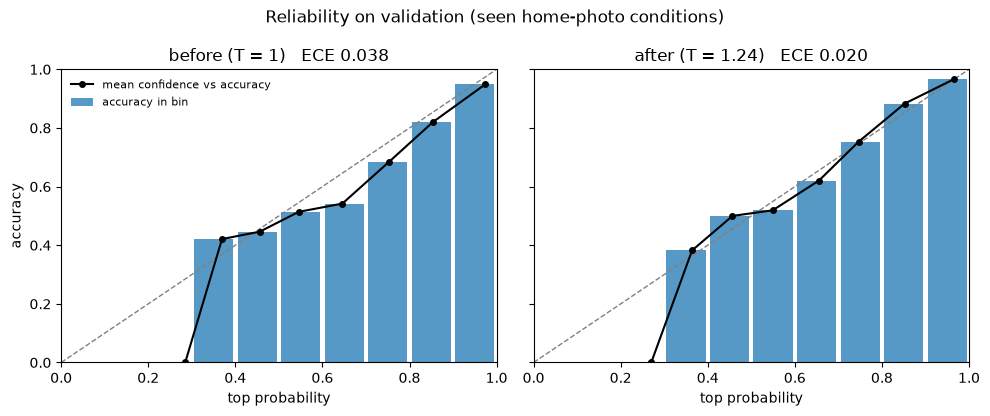

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, (title, t) in zip(axes, [("before (T = 1)", 1.0), (f"after (T = {T:.2f})", T)]):
    p = C.softmax(val_lg[seen], t)
    rel = C.reliability(p, y_val[seen])
    ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
    ax.bar(rel["bin_mid"], rel["accuracy"], width=0.09, alpha=0.75, label="accuracy in bin")
    ax.plot(rel["confidence"], rel["accuracy"], "o-", color="black", ms=4, label="mean confidence vs accuracy")
    ax.set_title(f"{title}   ECE {C.ece(p, y_val[seen]):.3f}")
    ax.set_xlabel("top probability")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("accuracy")
axes[0].legend(frameon=False, loc="upper left", fontsize=8)
fig.suptitle("Reliability on validation (seen home-photo conditions)")
plt.tight_layout()
fig.savefig(ARTIFACTS / "reliability_val.png", dpi=120, bbox_inches="tight")

The model was only mildly overconfident, so T is a little above 1. Temperature scaling never changes which class is on top, so accuracy and F1 are unchanged; only the probabilities move.

## 2. Thresholds

**`min_conf`**: the lowest top probability whose answers reach 95% accuracy on validation. Lower means more answers, higher means more "ask a person".

min_conf = 0.84


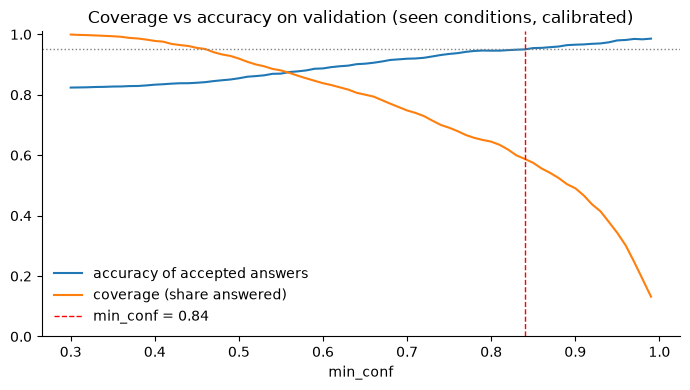

In [5]:
p_val = C.softmax(val_lg, T)
MIN_CONF, curve = C.tune_min_conf(p_val[seen], y_val[seen], target=TARGET_ACC)
print(f"min_conf = {MIN_CONF}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["min_conf"], curve["accuracy"], label="accuracy of accepted answers")
ax.plot(curve["min_conf"], curve["coverage"], label="coverage (share answered)")
ax.axhline(TARGET_ACC, color="grey", ls=":", lw=1)
ax.axvline(MIN_CONF, color="red", ls="--", lw=1, label=f"min_conf = {MIN_CONF}")
ax.set_xlabel("min_conf")
ax.set_ylim(0, 1.01)
ax.legend(frameon=False)
ax.set_title("Coverage vs accuracy on validation (seen conditions, calibrated)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(ARTIFACTS / "coverage_accuracy_val.png", dpi=120, bbox_inches="tight")

**`multi_conf`**: when no single class reaches `min_conf`, but the top two are both diseases, the second has at least `multi_conf` and together they reach `min_conf`, the status is `possibly_multiple` (both are reported and a person is asked to check). Otherwise it is `not_sure`.

The table shows the trade-off on validation. "top-2 has a present disease" checks the flagged answers against BRACOL's per-stress columns.

In [6]:
pres = C.present_classes(val_df[seen])
order = np.argsort(-p_val[seen], 1)
either = np.array([order[i, 0] in s or order[i, 1] in s for i, s in enumerate(pres)])
multi_stress = np.array([len(s) >= 2 for s in pres])
rows = []
for mu in [0.10, 0.15, 0.20, 0.25, 0.30]:
    st = C.status(p_val[seen], MIN_CONF, mu)
    pm = st == "possibly_multiple"
    rows.append({"multi_conf": mu, "confident": (st == "confident").mean(), "possibly_multiple": pm.mean(),
                 "not_sure": (st == "not_sure").mean(), "flagged leaves with 2+ stresses": multi_stress[pm].mean(),
                 "flagged with a present disease in top-2": either[pm].mean()})
pd.DataFrame(rows).set_index("multi_conf").round(3)

,confident,possibly_multiple,not_sure,flagged leaves with 2+ stresses,flagged with a present disease in top-2
multi_conf,,,,,
0.10,0.588,0.261,0.152,0.356,0.969
0.15,0.588,0.222,0.190,0.356,0.972
0.20,0.588,0.160,0.252,0.342,0.969
0.25,0.588,0.118,0.295,0.339,0.968
0.30,0.588,0.077,0.335,0.379,0.976


`multi_conf = 0.20` is a judgement call: the second disease must have at least a 1-in-5 probability. The top-2 hit rate is about the same at every threshold, so the choice mostly sets how many "not sure" photos become "possibly multiple". Both statuses route Noor to a person.

Base rate for the "2+ stresses" column: 22% of validation leaves carry a second stress.

In [7]:
thresholds = {"run": RUN, "temperature": round(T, 4), "min_conf": MIN_CONF, "multi_conf": MULTI_CONF,
              "target_confident_accuracy": TARGET_ACC, "fit_on": "val split, seen stress conditions pooled",
              "classes": CLASSES,
              "rule": ["confident if top1 >= min_conf",
                       "possibly_multiple if top1 and top2 are diseases, top2 >= multi_conf and top1 + top2 >= min_conf",
                       "otherwise not_sure"]}
(ARTIFACTS / "thresholds.json").write_text(json.dumps(thresholds, indent=2))
thresholds

{'run': 'scenario_v1',
 'temperature': 1.2379,
 'min_conf': 0.84,
 'multi_conf': 0.2,
 'target_confident_accuracy': 0.95,
 'fit_on': 'val split, seen stress conditions pooled',
 'classes': ['healthy', 'leaf_miner', 'rust', 'phoma', 'cercospora'],
 'rule': ['confident if top1 >= min_conf',
  'possibly_multiple if top1 and top2 are diseases, top2 >= multi_conf and top1 + top2 >= min_conf',
  'otherwise not_sure']}

## 3. Final evaluation on the test split (run once)

"Correct" means the top class equals BRACOL's **predominant** stress. `acc_when_confident` is what Noor gets when the app gives an answer; `confident_wrong` is the share of all photos where the app is confidently wrong, the case the fail-safe cannot catch.

In [8]:
test_lg, test_df = logits["test"], frames["test"]
p_test = C.softmax(test_lg, T)
per_condition = pd.DataFrame({cond: C.summarise(p_test[(test_df["condition"] == cond).to_numpy()],
                                                test_df[test_df["condition"] == cond], MIN_CONF, MULTI_CONF)
                              for cond in CONDITIONS}).T
per_condition.insert(0, "seen", [CONDITIONS[c][0] for c in per_condition.index])
per_condition.to_csv(ARTIFACTS / "test_by_condition.csv")
cols = ["acc", "macro_f1", "confident", "possibly_multiple", "not_sure", "acc_when_confident", "confident_wrong"]
per_condition.style.format({c: "{:.3f}" for c in cols}).background_gradient(cmap="Greens", subset=["acc", "macro_f1", "acc_when_confident"], vmin=0.4, vmax=1)

,seen,n,acc,macro_f1,confident,possibly_multiple,not_sure,acc_when_confident,confident_wrong
clean,True,202.000000,0.871,0.845,0.653,0.168,0.178,0.977,0.015
home background,True,202.000000,0.832,0.797,0.599,0.168,0.233,0.975,0.015
window side light,True,202.000000,0.866,0.846,0.653,0.153,0.193,0.985,0.010
dim warm lamp,True,202.000000,0.698,0.647,0.441,0.163,0.396,0.910,0.040
picked leaf curl,True,202.000000,0.856,0.833,0.634,0.168,0.198,0.992,0.005
budget camera,True,202.000000,0.837,0.808,0.559,0.208,0.233,0.991,0.005
handheld blur,True,202.000000,0.871,0.851,0.639,0.173,0.188,0.977,0.015
realistic weekend photo,True,202.000000,0.777,0.750,0.426,0.198,0.376,0.942,0.025
UNSEEN cool LED light,False,202.000000,0.851,0.838,0.550,0.173,0.277,0.973,0.015
UNSEEN forwarded photo,False,202.000000,0.762,0.737,0.485,0.248,0.267,0.959,0.020


              precision    recall  f1-score   support

     healthy      1.000     0.909     0.952        22
  leaf_miner      0.960     0.632     0.762        38
        rust      0.930     0.943     0.936        70
       phoma      0.925     0.942     0.933        52
  cercospora      0.515     0.850     0.642        20

    accuracy                          0.871       202
   macro avg      0.866     0.855     0.845       202
weighted avg      0.901     0.871     0.875       202



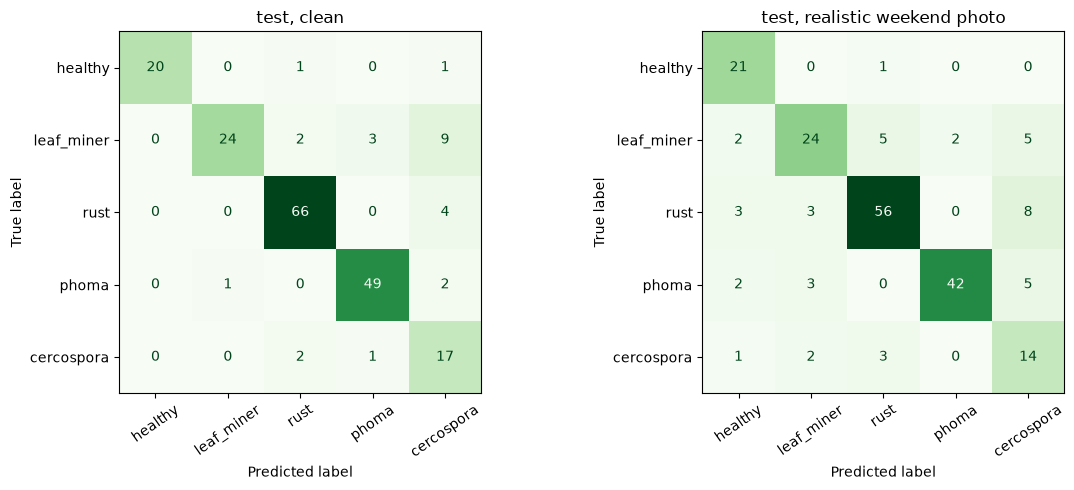

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cond in zip(axes, ["clean", "realistic weekend photo"]):
    m = (test_df["condition"] == cond).to_numpy()
    cm = confusion_matrix(test_df["label"][m], p_test[m].argmax(1), labels=range(len(CLASSES)))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=35)
    ax.set_title(f"test, {cond}")
plt.tight_layout()
fig.savefig(ARTIFACTS / "confusion_matrix.png", dpi=120, bbox_inches="tight")

m = (test_df["condition"] == "clean").to_numpy()
print(classification_report(test_df["label"][m], p_test[m].argmax(1), target_names=CLASSES, digits=3))

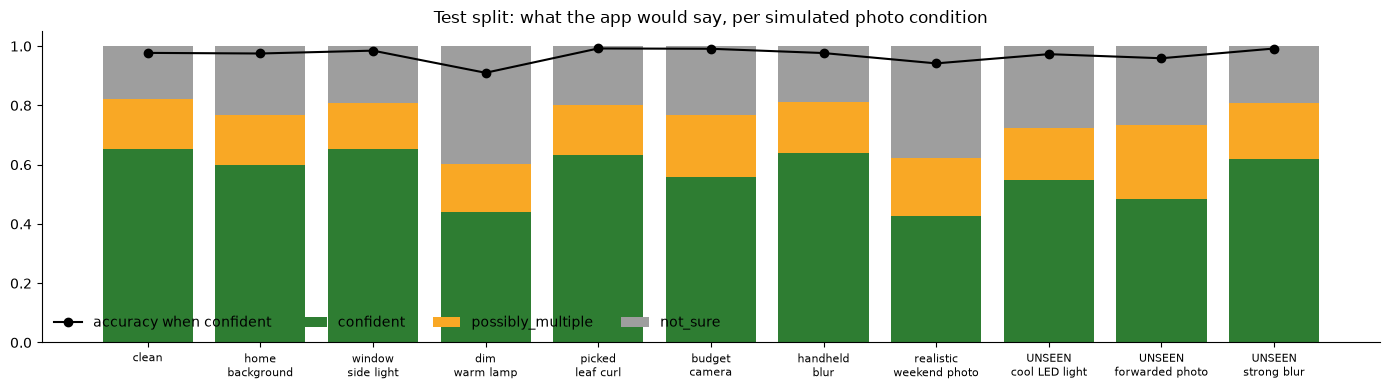

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
names = list(CONDITIONS)
bottom = np.zeros(len(names))
for col, color in [("confident", "#2e7d32"), ("possibly_multiple", "#f9a825"), ("not_sure", "#9e9e9e")]:
    ax.bar(names, per_condition[col], bottom=bottom, color=color, label=col)
    bottom += per_condition[col].to_numpy(float)
ax.plot(names, per_condition["acc_when_confident"], "ko-", label="accuracy when confident")
ax.set_xticks(range(len(names)), [n.replace(" ", "\n", 1) for n in names], fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, ncol=4, loc="lower left")
ax.set_title("Test split: what the app would say, per simulated photo condition")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(ARTIFACTS / "test_status_by_condition.png", dpi=120, bbox_inches="tight")

## 4. Fail-safe check: 59 mixed-stress leaves (BRACOL class 5)

These leaves were never trained on and have no single right answer. The model should mostly **not** be confident about them. We also check whether its top guess is at least one of the stresses actually present.

In [11]:
mix_lg, mix_df = logits["mixed_holdout"], frames["mixed_holdout"]
p_mix = C.softmax(mix_lg, T)
pres_mix = C.present_classes(mix_df)
top1_present = np.array([p_mix[i].argmax() in s for i, s in enumerate(pres_mix)])
st_mix = C.status(p_mix, MIN_CONF, MULTI_CONF)
rows = []
for cond in CONDITIONS:
    m = (mix_df["condition"] == cond).to_numpy()
    rows.append({"condition": cond, "seen": CONDITIONS[cond][0],
                 "flagged (not_sure or possibly_multiple)": (st_mix[m] != "confident").mean(),
                 "possibly_multiple": (st_mix[m] == "possibly_multiple").mean(),
                 "not_sure": (st_mix[m] == "not_sure").mean(),
                 "top-1 is a present stress": top1_present[m].mean(),
                 "confident and top-1 present": ((st_mix[m] == "confident") & top1_present[m]).mean()})
mixed = pd.DataFrame(rows).set_index("condition")
mixed.to_csv(ARTIFACTS / "mixed_holdout_by_condition.csv")
mixed.round(3)

,seen,flagged (not_sure or possibly_multiple),possibly_multiple,not_sure,top-1 is a present stress,confident and top-1 present
condition,,,,,,
clean,True,0.847,0.542,0.305,0.881,0.153
home background,True,0.847,0.441,0.407,0.831,0.153
window side light,True,0.864,0.424,0.441,0.881,0.136
dim warm lamp,True,0.831,0.373,0.458,0.780,0.136
picked leaf curl,True,0.864,0.407,0.458,0.881,0.136
budget camera,True,0.881,0.322,0.559,0.797,0.119
handheld blur,True,0.831,0.525,0.305,0.881,0.169
realistic weekend photo,True,0.881,0.305,0.576,0.831,0.068
UNSEEN cool LED light,False,0.898,0.390,0.508,0.780,0.102


In [12]:
def pick(df, cond, cols):
    return {c: round(float(df.loc[cond, c]), 4) for c in cols}

metrics = {
    "run": RUN, "thresholds": thresholds,
    "calibration_val": {"ece_seen_before": C.ece(C.softmax(val_lg[seen]), y_val[seen]),
                        "ece_seen_after": C.ece(p_val[seen], y_val[seen]),
                        "ece_unseen_before": C.ece(C.softmax(val_lg[~seen]), y_val[~seen]),
                        "ece_unseen_after": C.ece(p_val[~seen], y_val[~seen])},
    "test_clean": pick(per_condition, "clean", cols),
    "test_realistic_weekend_photo": pick(per_condition, "realistic weekend photo", cols),
    "test_mean_seen_excl_clean": per_condition[per_condition["seen"] & (per_condition.index != "clean")][cols].astype(float).mean().round(4).to_dict(),
    "test_mean_unseen": per_condition[~per_condition["seen"].astype(bool)][cols].astype(float).mean().round(4).to_dict(),
    "mixed_holdout_clean": mixed.loc["clean"].drop("seen").astype(float).round(4).to_dict(),
    "mixed_holdout_realistic": mixed.loc["realistic weekend photo"].drop("seen").astype(float).round(4).to_dict(),
    "notes": ["Stress conditions are synthetic re-renders of BRACOL photos, not real home photos.",
              "Correct = top-1 equals BRACOL's predominant stress; 38 of 202 test leaves carry a second stress.",
              "Thresholds fit on validation only; test and mixed holdout were scored once."],
}
(ARTIFACTS / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))
pd.DataFrame({k: metrics[k] for k in ["test_clean", "test_realistic_weekend_photo", "test_mean_seen_excl_clean", "test_mean_unseen"]}).round(3)

,test_clean,test_realistic_weekend_photo,test_mean_seen_excl_clean,test_mean_unseen
acc,0.871,0.777,0.820,0.825
macro_f1,0.845,0.750,0.790,0.808
confident,0.654,0.426,0.564,0.551
possibly_multiple,0.168,0.198,0.176,0.203
not_sure,0.178,0.376,0.260,0.246
acc_when_confident,0.977,0.942,0.967,0.975
confident_wrong,0.015,0.025,0.016,0.013
